<a href="https://colab.research.google.com/github/sebsn13/Spotify/blob/main/ENSEMBLE_SPOTIFY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#🎧 Phase 1

##Loading Spotify DataSet

In [81]:
import kagglehub
path = kagglehub.dataset_download("nelgiriyewithana/most-streamed-spotify-songs-2024")

Using Colab cache for faster access to the 'most-streamed-spotify-songs-2024' dataset.


In [82]:
import pandas as pd
import numpy as np


In [83]:
#df = pd.read_csv(f"{path}/most-streamed-spotify-songs-2024")
#THIS WONT LOAD ITS JUST A TESTING THE CODE BELOW IS THE RIGHT ONE

In [84]:
import os #helps fiding the
print(os.listdir(path))

['Most Streamed Spotify Songs 2024.csv']


`os (Operating System):` This is a built-in Python tool that lets your code talk directly to the computer it's running on (in this case, Google's Colab servers). It gives you the power to manage files, create folders, and check paths.

`listdir (List Directory):` A "directory" is just the old-school programmer word for a "folder". This command literally means: "Look inside this folder path and give me a list of everything you see."

In [85]:
df = pd.read_csv(f"{path}/Most Streamed Spotify Songs 2024.csv", encoding='latin-1')

By default, Pandas tries to read every CSV file using a standard text dictionary called `'utf-8'`.

But think about our dataset. It's **Spotify**! It is packed with international artist names (like Rosalía or Michael Bublé), wildly stylized track titles, and maybe even weird symbols. When Pandas tried to read the file with its standard 'utf-8' dictionary, it hit a weird character (that 0xfd byte) and panicked because it didn't know how to translate it.

We can use the *`encoding = 'latin-1'`* to have a better dictionary for this

In [86]:
df.head()

,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,...,SiriusXM Spins,Deezer Playlist Count,Deezer Playlist Reach,Amazon Playlist Count,Pandora Streams,Pandora Track Stations,Soundcloud Streams,Shazam Counts,TIDAL Popularity,Explicit Track
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,4/26/2024,QM24S2402528,1,725.4,"390,470,936","30,716","196,631,588",...,684,62.0,"17,598,718",114.0,"18,004,655","22,931","4,818,457","2,669,262",NaN,0
1,Not Like Us,Not Like Us,Kendrick Lamar,5/4/2024,USUG12400910,2,545.9,"323,703,884","28,113","174,597,137",...,3,67.0,"10,422,430",111.0,"7,780,028","28,444","6,623,075","1,118,279",NaN,1
2,i like the way you kiss me,I like the way you kiss me,Artemas,3/19/2024,QZJ842400387,3,538.4,"601,309,283","54,331","211,607,669",...,536,136.0,"36,321,847",172.0,"5,022,621","5,639","7,208,651","5,285,340",NaN,0
3,Flowers,Flowers - Single,Miley Cyrus,1/12/2023,USSM12209777,4,444.9,"2,031,280,633","269,802","136,569,078",...,"2,182",264.0,"24,684,248",210.0,"190,260,277","203,384",NaN,"11,822,942",NaN,0
4,Houdini,Houdini,Eminem,5/31/2024,USUG12403398,5,423.3,"107,034,922","7,223","151,469,874",...,1,82.0,"17,660,624",105.0,"4,493,884","7,006","207,179","457,017",NaN,1


In [87]:
df.columns

Index(['Track', 'Album Name', 'Artist', 'Release Date', 'ISRC',
       'All Time Rank', 'Track Score', 'Spotify Streams',
       'Spotify Playlist Count', 'Spotify Playlist Reach',
       'Spotify Popularity', 'YouTube Views', 'YouTube Likes', 'TikTok Posts',
       'TikTok Likes', 'TikTok Views', 'YouTube Playlist Reach',
       'Apple Music Playlist Count', 'AirPlay Spins', 'SiriusXM Spins',
       'Deezer Playlist Count', 'Deezer Playlist Reach',
       'Amazon Playlist Count', 'Pandora Streams', 'Pandora Track Stations',
       'Soundcloud Streams', 'Shazam Counts', 'TIDAL Popularity',
       'Explicit Track'],
      dtype='object')

In [88]:
df.shape #4600 songs and 29 features

(4600, 29)

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Track                       4600 non-null   object 
 1   Album Name                  4600 non-null   object 
 2   Artist                      4595 non-null   object 
 3   Release Date                4600 non-null   object 
 4   ISRC                        4600 non-null   object 
 5   All Time Rank               4600 non-null   object 
 6   Track Score                 4600 non-null   float64
 7   Spotify Streams             4487 non-null   object 
 8   Spotify Playlist Count      4530 non-null   object 
 9   Spotify Playlist Reach      4528 non-null   object 
 10  Spotify Popularity          3796 non-null   float64
 11  YouTube Views               4292 non-null   object 
 12  YouTube Likes               4285 non-null   object 
 13  TikTok Posts                3427 

In [90]:
df.count()

,0
Track,4600
Album Name,4600
Artist,4595
Release Date,4600
ISRC,4600
All Time Rank,4600
Track Score,4600
Spotify Streams,4487
Spotify Playlist Count,4530
Spotify Playlist Reach,4528


In [91]:
df.describe().round()

,Track Score,Spotify Popularity,Apple Music Playlist Count,Deezer Playlist Count,Amazon Playlist Count,TIDAL Popularity,Explicit Track
count,4600.0,3796.0,4039.0,3679.0,3545.0,0.0,4600.0
mean,42.0,64.0,55.0,32.0,25.0,NaN,0.0
std,39.0,16.0,72.0,54.0,26.0,NaN,0.0
min,19.0,1.0,1.0,1.0,1.0,NaN,0.0
25%,23.0,61.0,10.0,5.0,8.0,NaN,0.0
50%,30.0,67.0,28.0,15.0,17.0,NaN,0.0
75%,44.0,73.0,70.0,37.0,34.0,NaN,1.0
max,725.0,96.0,859.0,632.0,210.0,NaN,1.0


##EDA

We are using a pacakge library that generates graphics automatically, letting us check a quick aproximation regarding the data we are using

In [92]:
#!pip install 'ydata-profiling[notebook]'

In [93]:
#import ydata_profiling as prof
#profile = prof.ProfileReport(df, title='Spotify EDA Report')
#profile.to_file("output.html")
#profile

17.1% missing data, duplicate rows, and an "unsupported" feature type. Welcome to the wild west of real-world data!

#🎧 Phase 2  Data Cleaning & The Target Setup

###eliminating duplicates

In [94]:
df = df.drop_duplicates() #reassignment

##TARGET: hit or flop song using spotify streams as target

is 'Spotify Streams' an tex/object or number?

In [95]:
type(df['Spotify Streams']) #this doesnt look inside the container to tell what kind of data we are calling between []

pandas.core.series.Series

how can we ask pandas what type of data lives inside the dfs?

In [96]:
df['Spotify Streams'].dtype #O stands for object

dtype('O')

In [97]:
df['Spotify Streams']

,Spotify Streams
0,"390,470,936"
1,"323,703,884"
2,"601,309,283"
3,"2,031,280,633"
4,"107,034,922"
...,...
4595,"305,049,963"
4596,"52,282,360"
4597,"189,972,685"
4598,"145,467,020"


lets write the code that takes this column, removes the commas, converts it to a float, and saves it back into the df using
str.replace()

*   str.replace() -> we replaces string 'commas' with nothing
*   astype(float)



In [98]:
df['Spotify Streams'] = df['Spotify Streams'].str.replace(',', '').astype(float)

In [99]:
df['Spotify Streams']

,Spotify Streams
0,3.904709e+08
1,3.237039e+08
2,6.013093e+08
3,2.031281e+09
4,1.070349e+08
...,...
4595,3.050500e+08
4596,5.228236e+07
4597,1.899727e+08
4598,1.454670e+08


what is the warning from upstairs?

When you ran `df = df.drop_duplicates()` in the previous step, Pandas did something sneaky. Instead of building a brand new table in the computer's memory, it just put a pair of "glasses" over the old table that hid the two duplicate rows.

So, when you tried to permanently change the Spotify Streams column, Pandas panicked. It yelled: "Hey! You are trying to change data on a 'slice' (a view) of the original table! Are you sure you want to do this?"

The Fix:
To tell Pandas to officially sever the tie to the old data and build a brand new, independent table in memory, we use .copy().


In [100]:
df = df.copy()

##Building the Target

We want to define a 'Hit' song that has more than 500 million streams. So we create and new brand column called Target, ordering this feature to declare is each songs is greater than 500.000.000 (we are using boolean tools)

In [101]:
df['target'] = df['Spotify Streams'] > 1000000000
#we create a new column

In [102]:
df['target']

,target
0,False
1,False
2,False
3,True
4,False
...,...
4595,False
4596,False
4597,False
4598,False


In [103]:
df['target'] = df['target'].astype(int)
#the boolean answers are turned into 1s and 0s

In [104]:
df['target'].value_counts()

,count
target,
0,3999
1,599


Look at the numbers! 3999 flops and 599 Hits. This means the dataset is **imbalanced** (87% flops and 13% Hits)

In [105]:
df['target'].value_counts(normalize = True).round(2)*100

,proportion
target,
0,87.0
1,13.0


##2.1 Heatmap correlations

We have to decide which numeric and categorical features we should use in the test and training. We have to be careful to check if the featurees chosen are not disguised answer keys (very related to spotify streams)

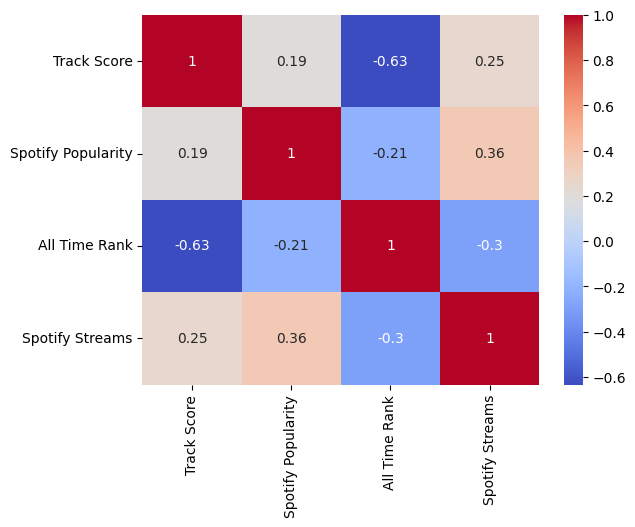

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

# Clean 'All Time Rank' column by removing commas and converting to numeric
df['All Time Rank'] = df['All Time Rank'].str.replace(',', '', regex=False).astype(float)

#subset of the df to check some features with the target one
df_1 = df[['Track Score', 'Spotify Popularity', 'All Time Rank', 'Spotify Streams']]
#saving the heatmap math
matrix = df_1.corr()

#heatmap graphic
sns.heatmap(matrix, annot = True, cmap = 'coolwarm')
#annot=true -> it tells the program to display the numerical data values directly inside each cell of the heatmap
plt.show()

#🎧 Phase 3: The X/y Split & The Cheat Code Trap

We always have to separate the **clues** (X Features) from the **answer keys** (Y Target: 1 or 0).

Attention! Be careful with Target Leakage. As we built the target with the Spotify Streams, we are giving this feature as the clue. We have to prevent the model from learning from the whole data because the aswers keys are going to be predicted from the same data all over again without actually looking for unexpected test data from other features, the model won't bother learning how tempo, artist_tier, or acousticness actually affect a song's success.

So let's see now how to split the dataset for train & test


**Why do we use axis=0/1**

Think of a DataFrame exactly like an Excel spreadsheet. It has two dimensions (rows and columns).

**axis=0 means ROWS**. Think of the number 0 as a big, round magnifying glass looking down the side of the table at the row numbers.

**axis=1 means COLUMNS.** Think of the number 1 as a tall, straight pillar holding up the column headers.

So, when you typed df.drop(['target', 'Spotify Streams'], axis=1), you were telling Pandas: **`"Look across the top pillar (the columns) for these names and throw them away."`** If you had accidentally typed axis=0, Pandas would have looked down the row numbers for row #target, panicked when it couldn't find it, and thrown an error!

In [107]:
from sklearn.model_selection import train_test_split

#creating X variable from features
#X = df['target', 'Spotify Streams'].drop(axis=1) #this is wrong
X = df.drop(['target', 'Spotify Streams'], axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#🎧 Phase 4: The Pipeline Setup & Splitting the Column Types

We have 27 features left, which is a lot to type manually. Instead of listing all of them, let's just pick a strong team of 6 features to train our model on.

In [108]:
cat_columns = ['Artist', 'Album Name', 'Explicit Track']
num_columns = ['Track Score', 'Spotify Popularity', 'All Time Rank' ]
X_train = X_train[cat_columns + num_columns]
X_test = X_test[cat_columns + num_columns]

By isolating caterogical from numerical features, we established a balanced structure to route the model into different preprocessing pipelines later

In [109]:
X_train.shape

(3678, 6)

In [110]:
y_train

,target
2793,0
3606,0
643,0
1270,0
2155,0
...,...
4428,0
466,1
3093,0
3774,0


In [111]:
X_train

,Artist,Album Name,Explicit Track,Track Score,Spotify Popularity,All Time Rank
2793,venbee,messy in heaven,0,26.6,59.0,2779.0
3606,DDG,I'm Geekin,1,22.7,60.0,3584.0
643,Dean Lewis,How Do I Say Goodbye,0,59.9,69.0,639.0
1270,Taylor Swift,THE TORTURED POETS DEPARTMENT,0,42.1,78.0,1264.0
2155,Imagine Dragons,Wrecked,0,31.0,64.0,2153.0
...,...,...,...,...,...,...
4428,David Morris,Carrying Your Love,0,19.9,50.0,4399.0
466,Kendrick Lamar,HUMBLE.,1,71.4,80.0,466.0
3093,AKDO,SUBMARINER - Single,0,24.9,74.0,3090.0
3774,Naza,Joli bï¿½ï¿,1,22.1,57.0,3755.0


#🎧 Phase 5: Preprocessor Engine

**Just to clarify**

In Scikit-Learn, there is a strict, unbreakable rule:

`OrdinalEncoder` is used exclusively for the features (X).

`LabelEncoder` is used exclusively for the target/answer key (y).
For this dataset, instead of using labelencoder now, we easily transformed the target feature with `.astype(int)`



In [112]:
y_train

,target
2793,0
3606,0
643,0
1270,0
2155,0
...,...
4428,0
466,1
3093,0
3774,0


the y variables are already 1/0s, but if we didnt use the astype(int). we could have put them through the LabelEncoder:


```python
import numpy as np
from sklearn.preprocessing import LabelEnconder
l_encoder = LabelEncoder()
y_train = l_encoder.fit_transform(y_train) #fit just for training! if we set it for testing we could have highly biased answers
y_test = l_encoder.transform(y_test)

```



In [113]:
from sklearn.compose import ColumnTransformer #traffic cop
from sklearn.preprocessing import OrdinalEncoder

#translator variable to encode categorical features as an integer array
encoder = OrdinalEncoder(handle_unknown = 'use_encoded_value', unknown_value=-1)
#building engine, we assign the variable a columntransformer(wiht its list )
preprocessor = ColumnTransformer(transformers=[('cat', encoder, cat_columns)], remainder = 'passthrough')

`handle_unknown='use_encoded_value, unknown_values=-1'` is set to handle the HIGH CARDINALITY from Artist and Album columns, as they have endless unique values. Maybe theres a indie artist that is not on the trainin set, so this assigns a safe -1 to unknown artists instead of panicking

`ColumnTransformer` splits the data
into two pipes, sending the text features as **cat_columns** into the *OrdinalEncoder*.

`remainder='passthrough'` lets the num_columns bypass the encoder to easily join the matrix

##some questions

**Why 'cat' inside the trasnformers and preprocessor column?**

We create it, we need a nametag for this pipe. If something happens with this transformer, we will receive a message warning the 'cat' failed.

**Why are we only using 6 out of 27 features?**
By stripping it down to 6 perfectly understood features, we are "testing the plumbing." Once we prove the pipe doesn't leak (Phase 6) and the model actually trains (Phase 7), we will simply remove the restriction and push all 27 features through the exact same pipe. This is related to
**Dimensionality Reduction or Feature Selection**


##🎧 Phase 5.2 : Defensive Engineering

This is just for data type validation and reverse translation integrity. Just like double-verification before we start processing the data

 1. **Data Type Validation**

we ask the computer if the array is mathemartically registered as integers

In [114]:
print('Is integer?', np.issubdtype(y_train.dtype, np.integer))

Is integer? True


In [115]:
#if false
if not np.issubdtype(y_train.dtype, np.integer):
    y_train = y_train.astype(int)

if your target was text, like `"Hit" and "Flop"`, or `"<=50K" and ">50K"` (like in the XG BOOSTING pdf example), calling .astype(int) will instantly crash the program. You cannot turn the word "Hit" into an integer using basic pandas math. That is exactly why the LabelEncoder exists—it is the heavy machinery required to translate raw text into numbers.

 2. **Reverse Translarion Integrity**

 we ask the computer to check if the translated answers match the original answers perfectly.

 `.inverse_transform()` flips 1s and 0s back to their original state.

 `np.array_equal` checks if two lists are identical



``` python
print('Integrity Check:', np.array_equal(y_train, l_encoder.inverse_transform(y_train)))
```







##Quick review on Pipelines & Dials

**Pipeline** -> fully automated and industgrial assembly line that we build once. From this moment on, whenever data arrives, the model routes the text to the translator, bypassing numbers and feeding a cleaner matrix directly into the algorightm. Theres no human error in the operations.

**Dials (Parameters)** -> Operationl Limits. Depth and learning rate (how deep into the data we should dive, how agressively we should correct the mistakes?)

**The Purpose of RandomizedSearchCV** -> If we wanted to change the dials manually and try 1000 diferrent combinations, it can take weeks. With the RandomizedSearchCV, we set boundaries and command the computer to do the brute-force mathematical labor.

#🎧 Phase 7 : Unleashing the CatBoost Titan

In [116]:
!pip install catboost
from sklearn.pipeline import Pipeline
from catboost import CatBoostClassifier


In [117]:
model = CatBoostClassifier(verbose=0)
my_pipeline = Pipeline(steps=[('prep', preprocessor), ('classifier', model)])
my_pipeline.fit(X_train, y_train) #trainig clues, training answers
preds_cb_lazy = my_pipeline.predict(X_test) # unseen_clues #y_pred
print(preds_cb_lazy[:5])

[0 0 0 0 0]


#🎧 Phase 7.2 : Evaluation

In [118]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, preds_cb_lazy))

[[778  36]
 [ 74  32]]


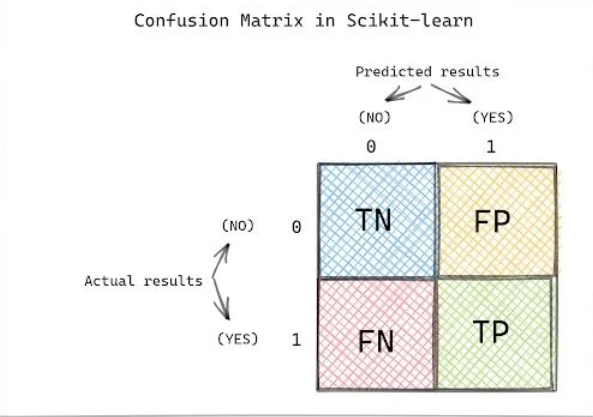

for a quick review https://builtin.com/data-science/confusion-matrix-python

In [119]:
report_1= classification_report(y_test, preds_cb_lazy)
print(report_1) #metric called RECALL

              precision    recall  f1-score   support

           0       0.91      0.96      0.93       814
           1       0.47      0.30      0.37       106

    accuracy                           0.88       920
   macro avg       0.69      0.63      0.65       920
weighted avg       0.86      0.88      0.87       920



This RECALL metric analyzes this statement: *Out of all the actual Hits that exist in reality, what percentage did the model successfully hunt down and find?*

We have to be careful because we have an **Imbalance Trap** (most of the songs are Flops). The accuracy is 0.88 because we have 87% Flops, so right now we are just blindly guessing flops. This is where we compare the percentage with the F1 Score, for the hits that is 0.37, super low!

**📝 Notes: The Averages (Macro vs. Weighted)**

When looking at the bottom of the **Classification Report**, the averages tell two completely different stories about your model.

`Macro Avg (The Truth Teller)`: This calculates the average by `treating both classes equally`, regardless of how many songs are in them. It takes the score for Flops, adds the score for Hits, and divides by 2. This is the true metric for an imbalanced model because it doesn't let the massive Flop category hide the terrible Hit category.

`Weighted Avg (The Liar)`: This calculates the average based on the volume of data (Support). Because 88% of our test data is Flops, the Flops' high scores completely dominate this average. It behaves exactly like "Accuracy"—it looks great (88%), but it is mathematically hiding the model's failure. For imbalanced datasets, ignore this metric.

**📝 Notes: The Core Metrics (Class 1 / Hits)**

**Support (The Headcount):** The literal number of true instances in the test exam.

Our Dataset: We had 814 actual Flops and 106 actual Hits.

**Recall (The Hunter's Metric):** Out of all the actual Hits that exist, what percentage did the model successfully find?

Our Dataset: Out of 106 actual Hits, the model only found 32. Our Recall is a terrible 0.30 (30%). It let 70% of the Hits slip through the cracks.

**F1-Score (The Lie Detector):** A strict `average of Precision and Recall.` It punishes models that just guess "Flop" every time to artificially inflate their accuracy.

Our Dataset: Our Hit category gets an F1-Score of 0.37. This is a failing grade. It proves the model is paralyzed by the Imbalance Trap and is terrified of guessing "Hit."

#⚖️ Phase 8 : Balancing the weights

To fix the Imbalance Trap, we have to change the rules of the game. We are rigging the system (manipulating) so missing a Hit costs huge points.

In [134]:
model_2 = CatBoostClassifier(auto_class_weights = 'Balanced', verbose=0) #rebuild model
my_pipeline_2 = Pipeline(steps=[('prep', preprocessor), ('classifier', model_2)]) #rebuild pipeline
my_pipeline_2.fit(X_train, y_train) #retrain
preds_cb_bal = my_pipeline_2.predict(X_test) #catboost balanced


In [121]:
print('Before balancing')
print(report_1)

Before balancing
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       814
           1       0.47      0.30      0.37       106

    accuracy                           0.88       920
   macro avg       0.69      0.63      0.65       920
weighted avg       0.86      0.88      0.87       920



In [135]:
report_2 = classification_report(y_test, preds_cb_bal)
print('after balancing')
print(report_2)

after balancing
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       814
           1       0.37      0.51      0.43       106

    accuracy                           0.84       920
   macro avg       0.65      0.70      0.67       920
weighted avg       0.87      0.84      0.85       920



**Precision-Recall Trade-off:**

**Recall skyrocketed (0.30 ➡️ 0.51):** This is a massive victory. By punishing the model for missing Hits, it became a much more aggressive hunter. It is now successfully finding over half (51%) of all actual Hits in the dataset, compared to just 30% before.

**Precision plummeted (0.47 ➡️ 0.37):** Because the model is now aggressively hunting for Hits, it has a "trigger-happy" problem. It is pointing at a lot of Flops and yelling "Hit!" (False Positives). When it guesses Hit, it is only right 37% of the time.

**Accuracy dropped (0.88 ➡️ 0.84):** This is actually a good thing. The model stopped lazily guessing "0" for every single song to artificially inflate its score. It took a hit to its overall accuracy in order to do the hard job of actually finding the 1s.

#⚖️ Phase 9 : RandomizedSearchCV

Automatic tool. Instead of guessing which dial/way is the best, this tool analyzes a bunch of possible options. It can record the F1 Score and spin them after a dozen of tests (10-20) with different dials. After this examination it tells you the exact mathematical configuration with the highest score.

We are using the learning rate, the depth and iterations we can improve on catboost with **`RandomizedSearchCV`**

In [123]:
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as st
#double underscore so the pipeline knows to send the change to the model, not the preprocessor
#parameter grid (the dials)
param_grid = {
    "classifier__iterations": st.randint(100,500),
    "classifier__learning_rate": st.uniform(0.01,0.3),
    "classifier__depth": st.randint(3,10)
}


**Search Engine creation**

``` python
random_search = RandomizedSearchCV(
      estimator, #the engine (the pipeline we created)
      param_distributions, #dials
      n_iter, #random combinations
      scoring, #judge success based on F1 with good percentage of True Positives
      cv, #cross validation, double checking the work k times
      verbose #we watch it work
      )
```



In [124]:
random_search = RandomizedSearchCV(
    estimator = my_pipeline_2,
    param_distributions = param_grid,
    n_iter = 10,
    scoring = 'f1',
    cv = 3,
    verbose = 2
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END classifier__depth=9, classifier__iterations=411, classifier__learning_rate=0.1696583563321081; total time=   9.7s
[CV] END classifier__depth=9, classifier__iterations=411, classifier__learning_rate=0.1696583563321081; total time=  10.9s
[CV] END classifier__depth=9, classifier__iterations=411, classifier__learning_rate=0.1696583563321081; total time=   9.4s
[CV] END classifier__depth=4, classifier__iterations=385, classifier__learning_rate=0.13306435148932488; total time=   1.3s
[CV] END classifier__depth=4, classifier__iterations=385, classifier__learning_rate=0.13306435148932488; total time=   0.7s
[CV] END classifier__depth=4, classifier__iterations=385, classifier__learning_rate=0.13306435148932488; total time=   0.7s
[CV] END classifier__depth=4, classifier__iterations=169, classifier__learning_rate=0.21805203248791888; total time=   0.2s
[CV] END classifier__depth=4, classifier__iterations=169, classifier__lear

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('prep',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('cat',
                                                                               OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                              unknown_value=-1),
                                                                               ['Artist',
                                                                                'Album '
                                                                                'Name',
                                                                                'Explicit '
                                                                                'Track'])])),
                                             ('classifier',
                                              CatBoostClassifier(auto_class_weights='Balanced', verbose=0))]),
                   param_distributions={'classifier__depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7dd66f44a750>,
                                        'classifier__iterations': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7dd66f4496a0>,
                                        'classifier__learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7dd66f7b8b90>},
                   scoring='f1', verbose=2)

In [125]:
#print the exact dial settings the mechanic chose as the winner
print("winning dials:", random_search.best_params_)



winning dials: {'classifier__depth': 4, 'classifier__iterations': 169, 'classifier__learning_rate': np.float64(0.21805203248791888)}


In [126]:
#print the highest F1 Score achieved during trianing
print("winning F1-Score", random_search.best_score_)

winning F1-Score 0.5113059292416314


We already generated the winning dials. All you have to do is make the model take the final examen

In [127]:
best_preds = random_search.predict(X_test)
print('RandomizedSearchCV with CatBoosting')
print(classification_report(y_test, best_preds))


RandomizedSearchCV with CatBoosting
              precision    recall  f1-score   support

           0       0.93      0.87      0.90       814
           1       0.35      0.52      0.42       106

    accuracy                           0.83       920
   macro avg       0.64      0.70      0.66       920
weighted avg       0.87      0.83      0.85       920



##Question: Why the F-1 Score dropped?
We are trying these huge titans with slight params, that's part of why the RandomizedSearchCV performed worse.



1.   **The iteration Starvation** -> the n_iter #random combinations are set to 10. Its just a tiny amount into a huge board of math possibilities. We need hundred of iterations for optimal hyperparameters (this may take hours)
2.   **The Lost Weights** -> The tuning engine optimizes the dials its given, but cannot fix the imbalances we discovered. As the base pipeline didn't have the auto_class_weights='Balanced' parameter actively enforced, meaning the engine spent its time perfectly tuning a model afraid of guessing 'hit'

So, the lesson here is that logical data manipulation (forcing the weights to punish missed Hits) is far more powerful than blindly letting a computer test random hyperparameters on a broken fundation.




#⚡️ Phase 10 : LightGBM Engine

In [128]:
from lightgbm import LGBMClassifier
model_lgb = LGBMClassifier(class_weight='balanced')
pipeline_lgb = Pipeline(steps=[('prep', preprocessor), ('classifier', model_lgb)])
pipeline_lgb.fit(X_train, y_train) #trainig clues, training answers with LightGBM
preds_lgb = pipeline_lgb.predict(X_test)


[LightGBM] [Info] Number of positive: 493, number of negative: 3185
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000502 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1113
[LightGBM] [Info] Number of data points in the train set: 3678, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [129]:
print('                       LightGBM Boost')
print(classification_report(y_test, preds_lgb))

                       LightGBM Boost
              precision    recall  f1-score   support

           0       0.93      0.88      0.91       814
           1       0.36      0.53      0.43       106

    accuracy                           0.84       920
   macro avg       0.65      0.70      0.67       920
weighted avg       0.87      0.84      0.85       920



#💪 Phase 11 : XG Boosting

In [130]:
from xgboost import XGBClassifier
model_xgb= XGBClassifier(scale_pos_weight=8)
#as we have 8 times more flops than hits, this matchematically multiplies the penalty for missing a hit by 8
pipeline_xgb = Pipeline(steps=[('prep', preprocessor), ('classifier', model_xgb)])
pipeline_xgb.fit(X_train, y_train)
preds_xgb = pipeline_xgb.predict(X_test)
print('                       XG Boost')
print(classification_report(y_test, preds_xgb))


                       XG Boost
              precision    recall  f1-score   support

           0       0.92      0.89      0.90       814
           1       0.32      0.40      0.35       106

    accuracy                           0.83       920
   macro avg       0.62      0.64      0.63       920
weighted avg       0.85      0.83      0.84       920



#🥇 Phase 12 : Comparison Matrix

we can check all the reports together, creating a dictionary.

A) Generate predictions from every engine we built

In [131]:
preds_baseline = my_pipeline.predict(X_test)
preds_balanced =  my_pipeline_2.predict(X_test)
#bests_preds is saved from RandomizedSearchCV
#preds_lgb & preds_xgb saved from lasts phases

B) Translate all preds into background data dictionaries

In [132]:
base_report = classification_report(y_test, preds_cb_lazy, output_dict = True) #catboost lazy
bal_report = classification_report(y_test, preds_cb_bal, output_dict = True) #catboost balanced
rs_report = classification_report(y_test, best_preds, output_dict = True)
lgb_report = classification_report(y_test, preds_lgb, output_dict = True)
xgb_report = classification_report(y_test, preds_xgb, output_dict = True)

C) Getting only f1_Score and recall for the '1' class (Hits)

In [136]:
results = [
    {'Titan Engine': '1. CatBoost (Lazy/Unbalanced)',
     'Recall (Found Hits)': base_report['1']['recall'],
     'F1-Score (Hit Grade)': base_report['1']['f1-score']},

    {'Titan Engine': '2. CatBoost (Weighted/Balanced)',
     'Recall (Found Hits)': bal_report['1']['recall'],
     'F1-Score (Hit Grade)': bal_report['1']['f1-score']},

    {'Titan Engine': '3. CatBoost (RandomizedSearchCV)',
     'Recall (Found Hits)': rs_report['1']['recall'],
     'F1-Score (Hit Grade)': rs_report['1']['f1-score']},

    {'Titan Engine': '4. LightGBM (Weighted/Balanced)',
     'Recall (Found Hits)': lgb_report['1']['recall'],
     'F1-Score (Hit Grade)': lgb_report['1']['f1-score']},

    {'Titan Engine': '5. XGBoost (Weighted/Balanced)',
     'Recall (Found Hits)': xgb_report['1']['recall'],
     'F1-Score (Hit Grade)': xgb_report['1']['f1-score']},

]

D) Now we build a DataFrame and sort it strictly by F1-Score

In [138]:
scorecard = pd.DataFrame(results)
scorecard = scorecard.sort_values(by='F1-Score (Hit Grade)', ascending = False).reset_index(drop=True)
print("                                🏆 SPOTIFY ENSEMBLE: THE ULTIMATE SCORECARD 🏆\n")
print(scorecard.round(3))

                                🏆 SPOTIFY ENSEMBLE: THE ULTIMATE SCORECARD 🏆

                       Titan Engine  Recall (Found Hits)  F1-Score (Hit Grade)
0   2. CatBoost (Weighted/Balanced)                0.509                 0.430
1   4. LightGBM (Weighted/Balanced)                0.528                 0.429
2  3. CatBoost (RandomizedSearchCV)                0.519                 0.415
3     1. CatBoost (Lazy/Unbalanced)                0.302                 0.368
4    5. XGBoost (Weighted/Balanced)                0.396                 0.353


#Advanced Concepts Archive
(For Future Deployment)

1. The Thunderdome (search_space)
The Concept: Instead of tuning one algorithm at a time, we create a massive dictionary containing multiple different algorithms (XGBoost, LightGBM, CatBoost) and all of their respective dials.

The Execution: We pass this entire space into RandomizedSearchCV. The computer acts as an automated arena, forcing all models to train, cross-validate, and compete against each other simultaneously.

When to use it: When you have a clean, finalized pipeline and you want the computer to run overnight to find the absolute mathematically superior model without human intervention.

2. The ROC Curve & AUC Metric
The Concept: Algorithms do not actually guess "1" or "0". They calculate a probability (e.g., "I am 82% confident this is a Hit"). The ROC Curve plots the model's True Positive Rate against its False Positive Rate across every possible probability threshold.

The Metric (AUC): The Area Under the Curve (AUC) grades the model from 0.0 to 1.0. A perfect model is 1.0. A useless model that just flips a coin is a flat diagonal line at 0.5.

The Limitation: ROC AUC is dangerously optimistic on highly imbalanced datasets. If 87% of the data is Flops, the model gets a massive amount of "True Negatives," which artificially inflates the ROC score and hides the fact that it is failing to find the rare Hits.

3. CatBoost Native Text Processing (cat_features)
The Concept: CatBoost (Categorical Boosting) was built by Yandex specifically to handle raw text without needing mathematical translators.

The Execution: Instead of building a Scikit-Learn ColumnTransformer with an OrdinalEncoder, you bypass the pipeline entirely. You just give CatBoost the raw text columns and specify the cat_features parameter. It uses a proprietary internal engine to calculate the statistical weight of the words on the fly.

When to use it: When a dataset is completely dominated by high-cardinality categorical text (like thousands of unique Artist names or Cities), bypassing the pipeline to use CatBoost's native engine often yields higher accuracy and faster training times.

4. The Path to a Higher F1-Score
The Reality: We hit a wall at a 0.43 F1-Score. Tuning the hyperparameters might squeeze that up to 0.48 or 0.50, but it won't miraculously jump to 0.85.

The Fix: Algorithm tuning is the last 10% of the job. To drastically improve an F1-Score, we must go backward to the data. We need Feature Engineering (creating better clues, like combining 'Tempo' and 'Danceability' into a new variable) or we need more data points. The model is only as smart as the clues it is given.